# Water-use data available from USGS

The U.S. Geological Survey maintains national data bases of water-use information. The data are collected and compiled every five years for each State, the District of Columbia, Puerto Rico, and the U.S. Virgin Islands. County, State, and national water-use estimates may be downloaded from the National Water Information System Web (NWISWeb) interface, [**Water Data for the Nation**](http://waterdata.usgs.gov/), by selecting the Water Use button or data category pull-down. Data on NWISWeb represent the current best estimates, and may have been revised from previous publications. Data available from the links below generally reflect the published report, and may have been revised in subsequent analyses.

**Note: State-level data from 1950-1980 and watershed data are not available on NWISWeb.**

Other files, such as lists of county names, graphics, and charts, are also available for some years.

* [Download 2015 publication data for counties](https://water.usgs.gov/watuse/data/data2015.html)
* [Download 2010 publication data for counties](https://water.usgs.gov/watuse/data/2010/index.html)
* [Download 2005 publication data for counties](https://water.usgs.gov/watuse/data/2005/index.html)
* [Download 2000 publication data for counties](https://water.usgs.gov/watuse/data/2000/index.html)
* [Download 2000 publication data for principal aquifers](https://water.usgs.gov/watuse/data/2000/aquifer.html)
* [Download 1995 publication data for counties and watersheds](https://water.usgs.gov/watuse/data/1995/index.html)
* [Download 1990 publication data for counties and watersheds](https://water.usgs.gov/watuse/data/1990/index.html)
* [Download 1985 publication data for counties and watersheds](https://water.usgs.gov/watuse/data/1985/index.html)
* [Download 1950-1980 publication data for States](https://www.sciencebase.gov/catalog/item/584f00cee4b0260a373819db)


In [1]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/extract_usgs_livestock.py

Fetching USGS sources:   0%|          | 0/8 [00:00<?, ?file/s]

State-Level  1960-1980:   0%|          | 0/5 [00:00<?, ?yr/s]

County-Level 1985-2015:   0%|          | 0/7 [00:00<?, ?yr/s]

Done.
  state-level     245 rows x  9 cols  (1960-1980)  ->  usgs_livestock_state_1960_1980.feather
  county-level 21,768 rows x 10 cols  (1985-2015)  ->  usgs_livestock_county_1985_2015.feather
  scope     conus
  tables    /scratch/hdagne1/LivestockWaterUse/data/usgs_ls_state_county_1960_2015
  NOTE: 2 rows have no county name (retired FIPS codes; see the QA report)


## USDA NASS Census Data

The U.S. Department of Agriculture (USDA), National Agricultural Statistics Service (NASS), provides large agricultural datasets through its **Datasets** portal. Download agricultural statistics large datasets using .gz files. Zip Files, like .gz files, are compressed, or zipped, to save storage space and/or to bundle several files together. The files are unzipped in Linux, Windows or Mac environments. Even though you can see what is in the .gz file, you must unzip the file before you can open the individual files in the archive. Programmers, analysts, and researchers commonly use .gz files to import large datasets into their preferred software for further analysis.

### Census Data

* **qs.census2002.txt.gz**
* **qs.census2007.txt.gz**
* **qs.census2012.txt.gz**
* **qs.census2017.txt.gz**
* **qs.census2022.txt.gz**

**Source:** [USDA NASS — Datasets](https://www.nass.usda.gov/datasets/?utm_source=chatgpt.com)


In [10]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/usda_livestock.py

Fetching NASS census:   0%|          | 0/5 [00:00<?, ?file/s]

Parsing census years:   0%|          | 0/5 [00:00<?, ?yr/s]

Done.
  combined     52,826 rows x 9 cols  (2002-2022, 4 types, 3,062 counties)
  dairy_cattle  11,516 rows  (2,963 counties)  ->  usda_dairy_cattle_county_2002_2022.feather
  beef_cattle  15,091 rows  (3,050 counties)  ->  usda_beef_cattle_county_2002_2022.feather
  poultry      14,313 rows  (3,042 counties)  ->  usda_poultry_county_2002_2022.feather
  hogs         11,906 rows  (2,917 counties)  ->  usda_hogs_county_2002_2022.feather
  scope      conus
  tables     /scratch/hdagne1/LivestockWaterUse/data/usda_census


# Climate factors


| Variable                             | Description                                                                   | Source                                                                                                                                                                |
| ------------------------------------ | ----------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Temperature (`temp_c`)**           | 2-m air temperature (°C)                                                      | [ERA5-Land Monthly Aggregated – Google Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR?utm_source=chatgpt.com) |
| **Relative humidity (`rh_pct`)**     | Monthly RH (%) derived from 2-m temperature & dewpoint                        | ERA5-Land; RH calculated using Magnus–Tetens                                                                                                                          |
| **Precipitation (`precip_mm`)**      | Monthly total precipitation (mm)                                              | ERA5-Land                                                                                                                                                             |
| **Wind (`wind2_kmh`)**               | 2-m wind speed (km/h), derived from 10-m u/v wind components                  | ERA5-Land + FAO-56 conversion                                                                                                                                         |
| **Solar radiation (`rs_mj_m2_day`)** | Mean daily surface downward shortwave radiation (MJ m⁻² day⁻¹)                | ERA5-Land                                                                                                                                                             |
| **Sunlight (`sunlight_h`)**          | Actual monthly sunshine duration (hours/day), derived using Angström–Prescott | ERA5-Land radiation + FAO-56                                                                                                                                          |
| **CETI (`ceti`)**                    | Current Effective Temperature Index for livestock heat load                   | Derived from temperature, RH, 2-m wind, and sunlight using NASEM (2016) Eq. 19-103                                                                                    |
| **County area (`area_km2`)**         | County area (km²)                                                             | [US Census TIGER/Line 2018 – Google Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_Counties?utm_source=chatgpt.com)             |


In [76]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py


Successfully saved authorization token.


ERA5 county:   0%|          | 0/63 [00:00<?, ?yr/s]

ERA5 state:   0%|          | 0/63 [00:00<?, ?yr/s]

Done.
  Precp_county_level_1960_2022.feather         2,363,256 rows x  9 cols
  Temp_county_level_1960_2022.feather          2,363,256 rows x  9 cols
  RH_county_level_1960_2022.feather            2,363,256 rows x  9 cols
  Wind_county_level_1960_2022.feather          2,363,256 rows x  9 cols
  Sunlight_county_level_1960_2022.feather      2,363,256 rows x  9 cols
  Radiation_county_level_1960_2022.feather     2,363,256 rows x  9 cols
  CETI_county_level_1960_2022.feather          2,363,256 rows x  9 cols
  Area_county_level_1960_2022.feather              3,108 rows x  9 cols
  granularity  county-month
  counties 3,108 | states 49 | 1960-2022
  tables   /scratch/hdagne1/LivestockWaterUse/data/climate


  Precp   climatology  n=3,108  min     0.00  median  1062.36  max  2291.11  |  6 bins [354.1 .. 1446.9]
  Temp    climatology  n=3,107  min    -1.60  median    12.72  max    24.00  |  6 bins [3.9 .. 21.4]   MISSING 1
  RH      climatology  n=3,107  min    27.03  median    67.86  max    81.40  |  6 bins [42.9 .. 75.6]   MISSING 1


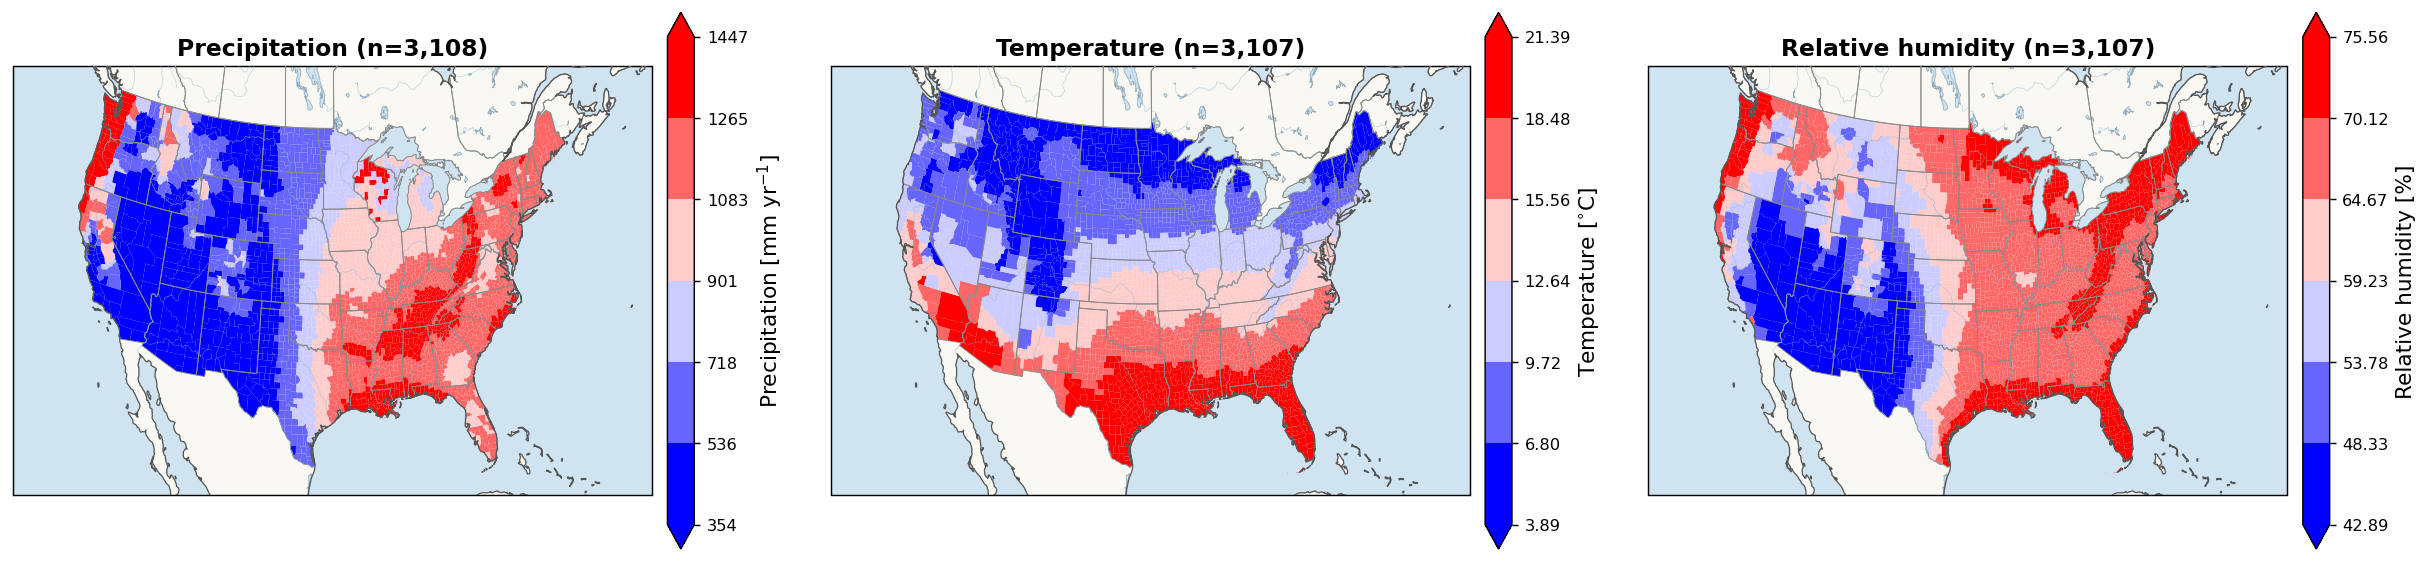

In [2]:
%run /scratch/hdagne1/LivestockWaterUse/figures/climate_factors_plot.py

# USGS Livestock Water use

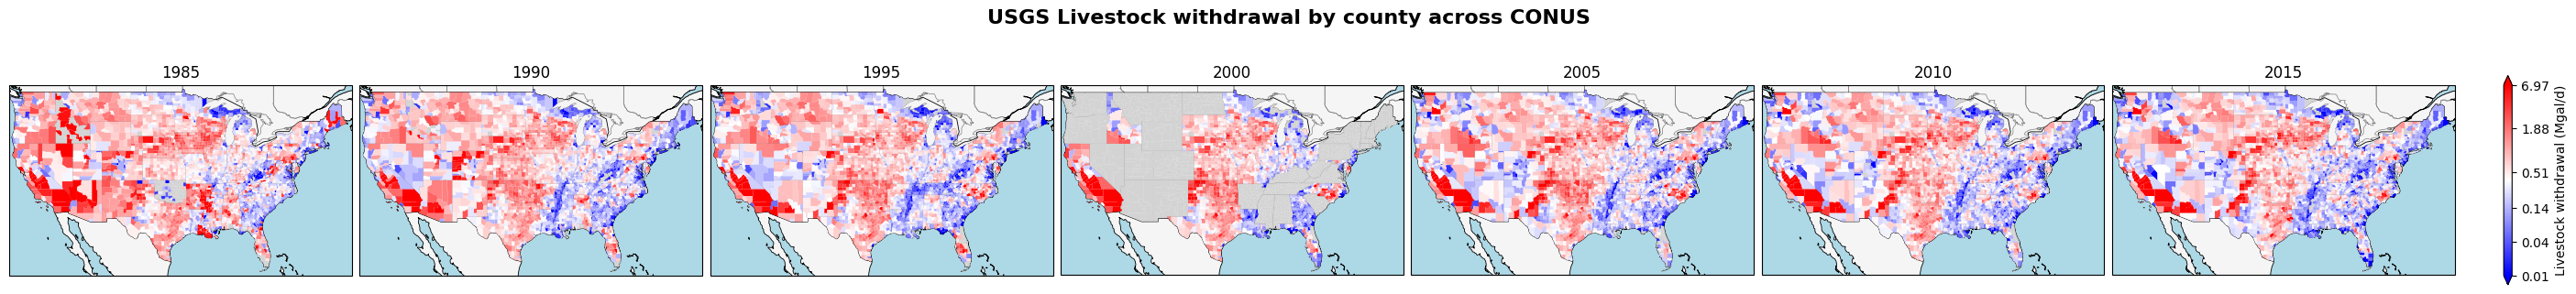

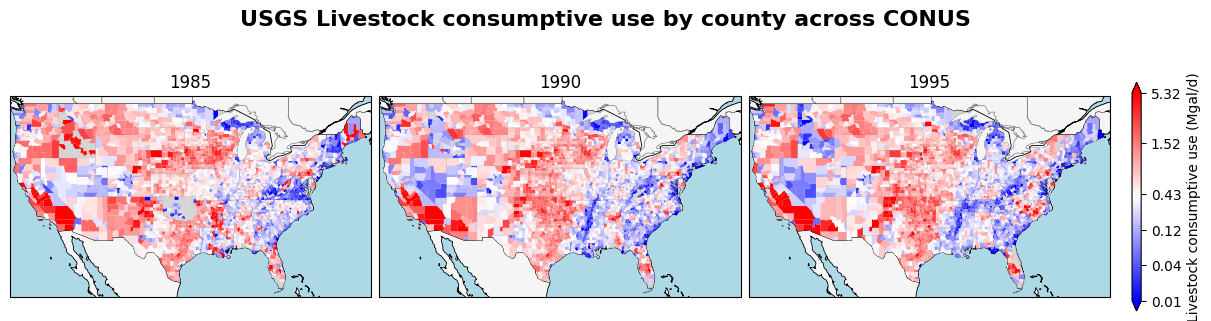

In [30]:
%run /scratch/hdagne1/LivestockWaterUse/figures/usgs_livestock_wateruse_plot.py

# County maps of livestock inventory, 2002–2022

One figure per livestock type, five panels (census years) sharing a singlelog colour scale so the years are directly comparable. Grey counties have no reported value: NASS suppresses counts that would
identify an individual operation, so these are unknown, not zero.

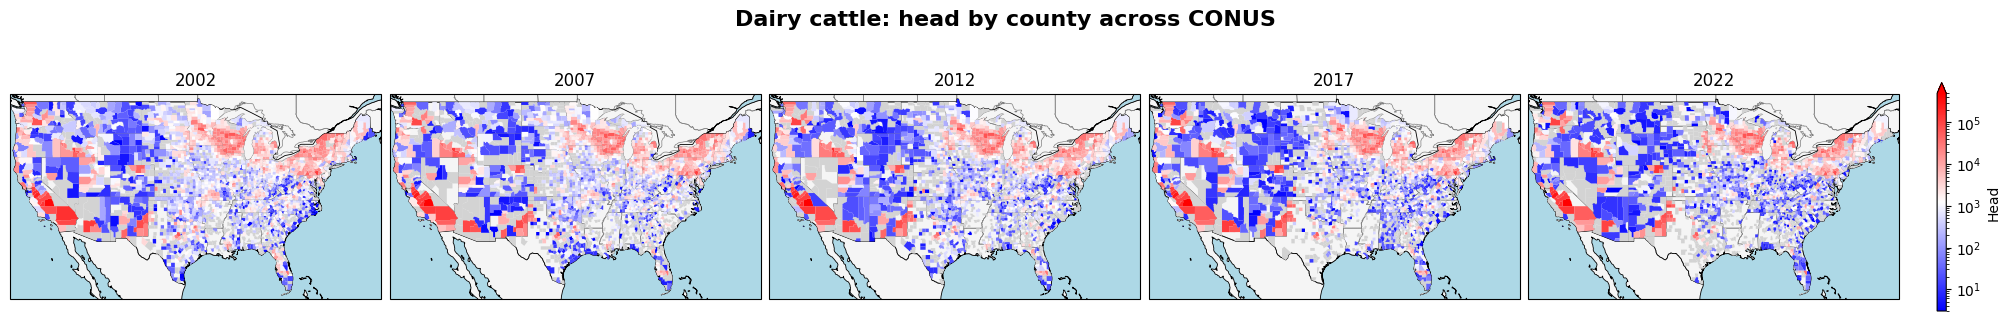

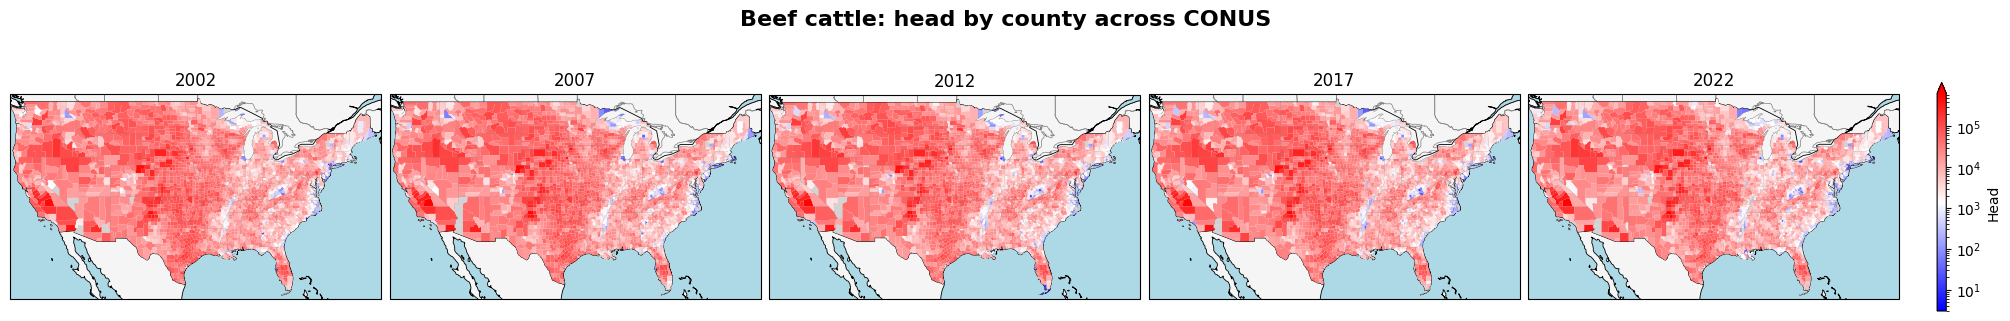

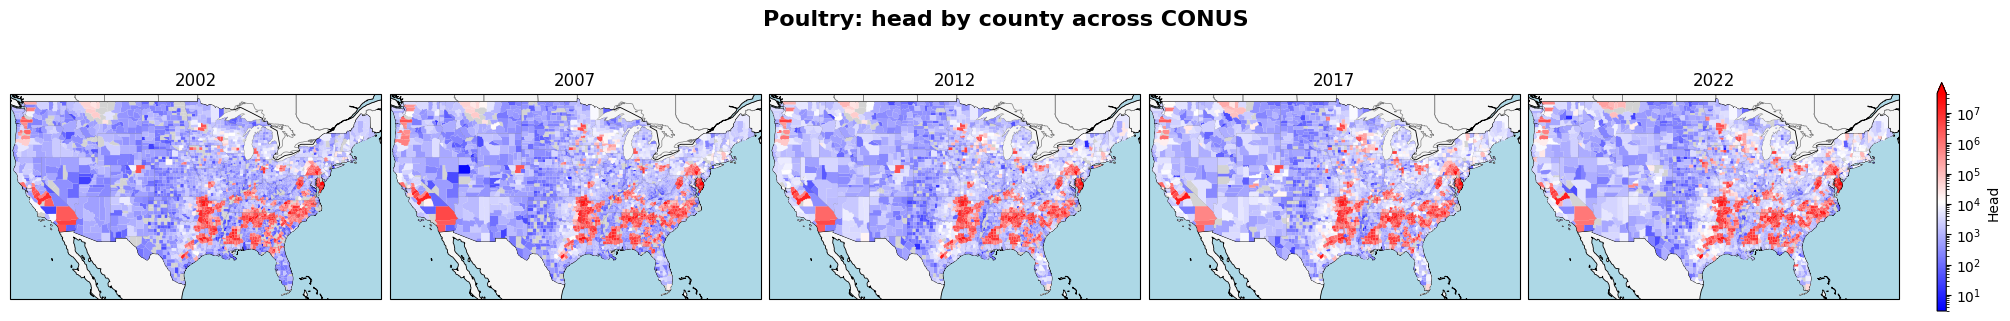

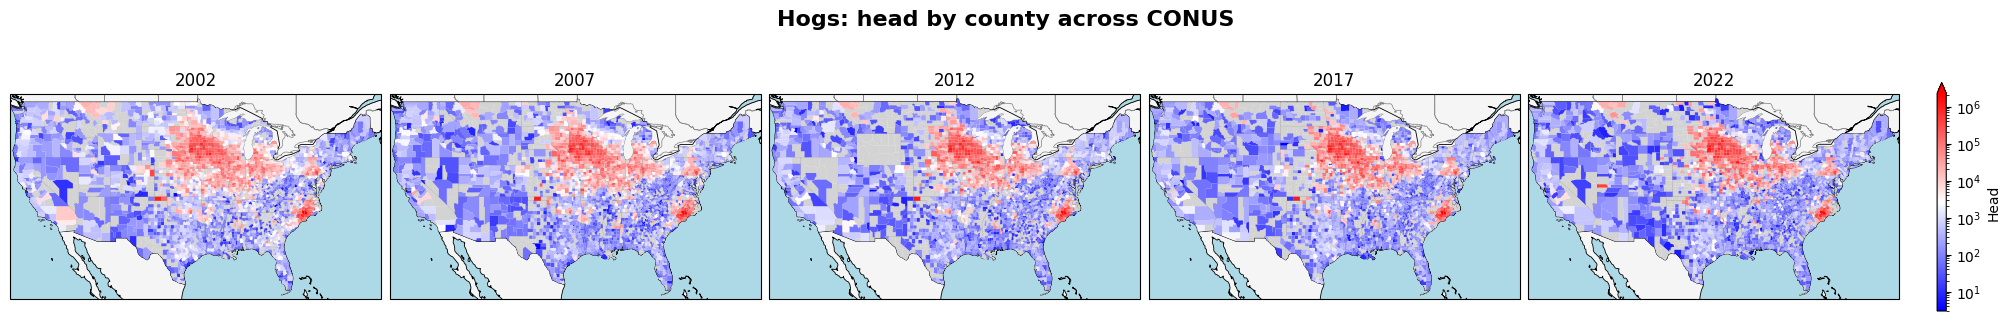

In [31]:
%run /scratch/hdagne1/LivestockWaterUse/figures/usda_census_plot.py

# MLR fitting:

In [11]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/wcc_mlr.py

Generating WCC samples:   0%|          | 0/4 [00:00<?, ?type/s]

Fitting MLR surrogates:   0%|          | 0/4 [00:00<?, ?type/s]

Generating surrogate WCC:   0%|          | 0/4 [00:00<?, ?type/s]

Done.
  dairy_cattle    50,000 samples  R2 test 0.7583  RMSPE   8.3%
  beef_cattle     50,000 samples  R2 test 0.9587  RMSPE   7.7%
  hogs            50,000 samples  R2 test 0.8920  RMSPE   8.3%
  poultry         50,000 samples  R2 test 0.9293  RMSPE   7.3%
  files      wcc_samples_<type>.feather      literature WCC + surrogate
             wcc_surrogate_<type>.feather    independent draw, surrogate WCC
             wcc_mlr_surrogate_all.feather   wide, one column pair per type
             wcc_mlr_coefficients.feather / wcc_mlr_equations.feather
  basis      drinking
  tables     /scratch/hdagne1/LivestockWaterUse/data/wcc_mlr


| Variable                       | Description                                      | Source                                                                                                                                                                |
| ------------------------------ | ------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`dmi_kg_d`**                 | Dry matter intake (kg/day)                       | Livestock literature-based physiological input                                                                                                                        |
| **`bw_kg`**                    | Body weight (kg)                                 | Livestock literature-based physiological input                                                                                                                        |
| **`age_months` / `age_weeks`** | Animal/herd/flock age                            | Sampled physiological state                                                                                                                                           |
| **`temp_c`**                   | Mean air temperature (°C)                        | [ERA5-Land Monthly Aggregated – Google Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR?utm_source=chatgpt.com) |
| **`temp_min_c`**               | Daily minimum temperature (°C)                   | Derived from `temp_c` and sampled diurnal temperature range                                                                                                           |
| **`rh_pct`**                   | Relative humidity (%)                            | ERA5-Land                                                                                                                                                             |
| **`wind_kmh`**                 | Wind speed (km/h)                                | ERA5-Land 10-m wind components, converted to km/h                                                                                                                     |
| **`sunlight_h`**               | Daily sunlight duration (h)                      | Derived from ERA5-Land radiation using FAO-56                                                                                                                         |
| **`lactating`**                | Fraction of dairy herd that is lactating         | Assumed/sample-generated herd characteristic                                                                                                                          |
| **`breeding`**                 | Fraction of hog inventory that is breeding stock | Assumed/sample-generated herd characteristic                                                                                                                          |
| **`layer`**                    | Fraction of poultry flock that is layers         | Assumed poultry composition; `broiler_fraction = 0.78`                                                                                                                |
| **`milk_kg_d`**                | Milk yield (kg/day)                              | Derived from DMI and lactating fraction                                                                                                                               |
| **`ceti`**                     | Current Effective Temperature Index              | NASEM (2016), Eq. 19-103                                                                                                                                              |
| **`water_feed_ratio`**         | Water-to-feed ratio                              | Swine and poultry literature-based relationships                                                                                                                      |
| **`wcc_l_d`**                  | Literature-based water consumption (L/day/head)  | Published livestock water-intake equations                                                                                                                            |
| **`wcc_gal_d`**                | Water consumption (gal/day/head)                 | Converted from `wcc_l_d`                                                                                                                                              |
| **`wcc_mlr_l_d`**              | WCC predicted by MLR surrogate (L/day/head)      | MLR fitted to literature-based samples                                                                                                                                |
| **`wcc_mlr_gal_d`**            | MLR WCC (gal/day/head)                           | Converted from `wcc_mlr_l_d`                                                                                                                                          |


  Dairy cattle   n= 50,000  slope=0.7669  intercept=5.51  R2=0.7652  RMSE=1.70  R2(1:1)=0.7652
  Beef cattle    n= 50,000  slope=0.9540  intercept=0.501  R2=0.9553  RMSE=0.863  R2(1:1)=0.9553
  Hogs           n= 50,000  slope=0.8895  intercept=0.185  R2=0.8912  RMSE=0.134  R2(1:1)=0.8912
  Poultry        n= 50,000  slope=0.9264  intercept=3.02e-03  R2=0.9312  RMSE=3.03e-03  R2(1:1)=0.9312


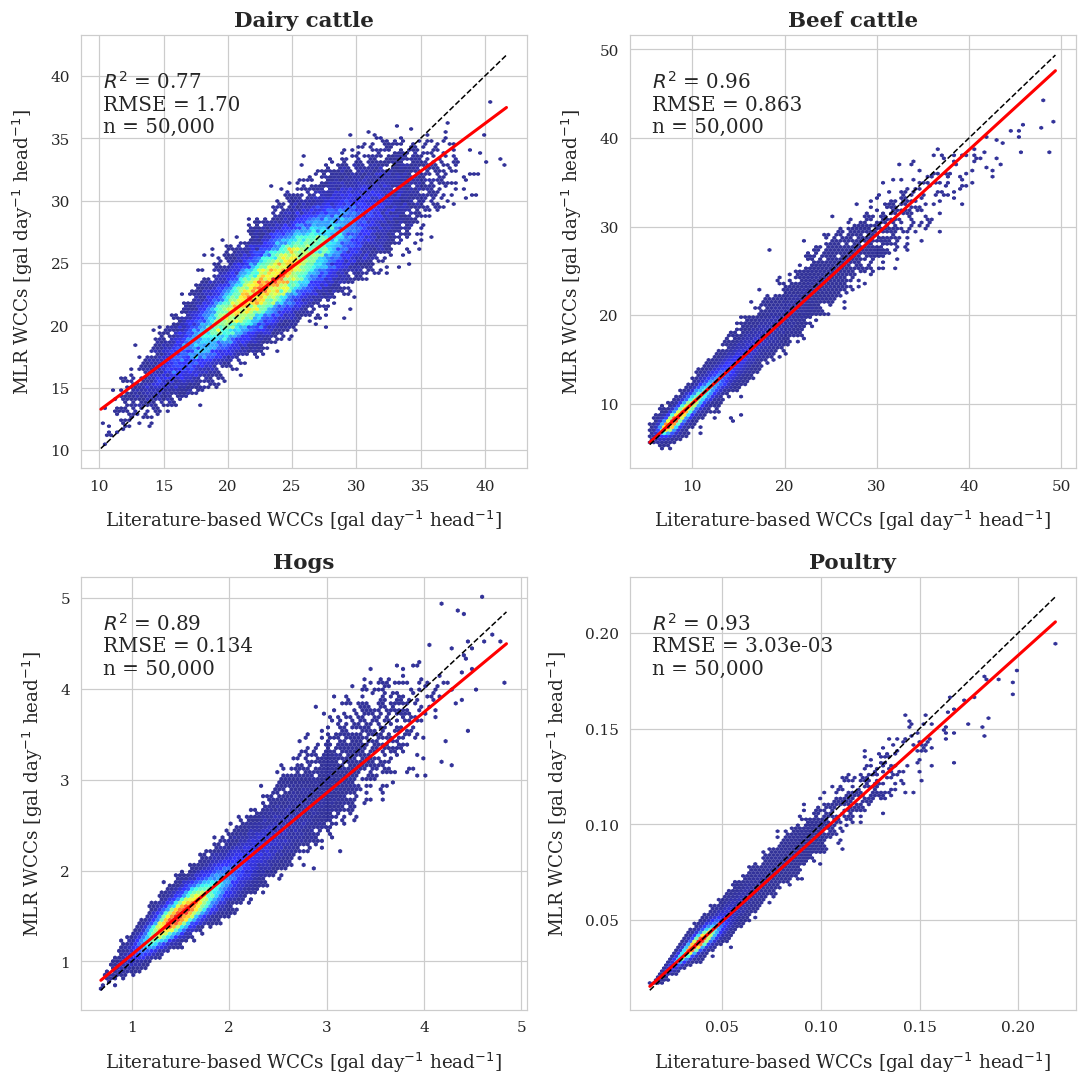

In [12]:
%run /scratch/hdagne1/LivestockWaterUse/figures/mlr_plot.py

# Transfer WCC to County-level

In [ ]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/wcc_ann_downscale.py

Downscaling WCC:   0%|          | 0/4 [00:00<?, ?type/s]

  training dairy_cattle:   0%|          | 0/400 [00:00<?, ?epoch/s]

  Dairy cattle   both        n=40,000  R2=0.7297  RMSE=6.88  bias=-0.095  best epoch 120
  Beef cattle    both        n=40,000  R2=0.9671  RMSE=2.84  bias=0.023  best epoch 125
  Hogs           both        n=40,000  R2=0.4522  RMSE=1.55  bias=3.25e-03  best epoch 30
  Poultry        both        n=40,000  R2=0.7154  RMSE=0.019  bias=-5.69e-04  best epoch 204


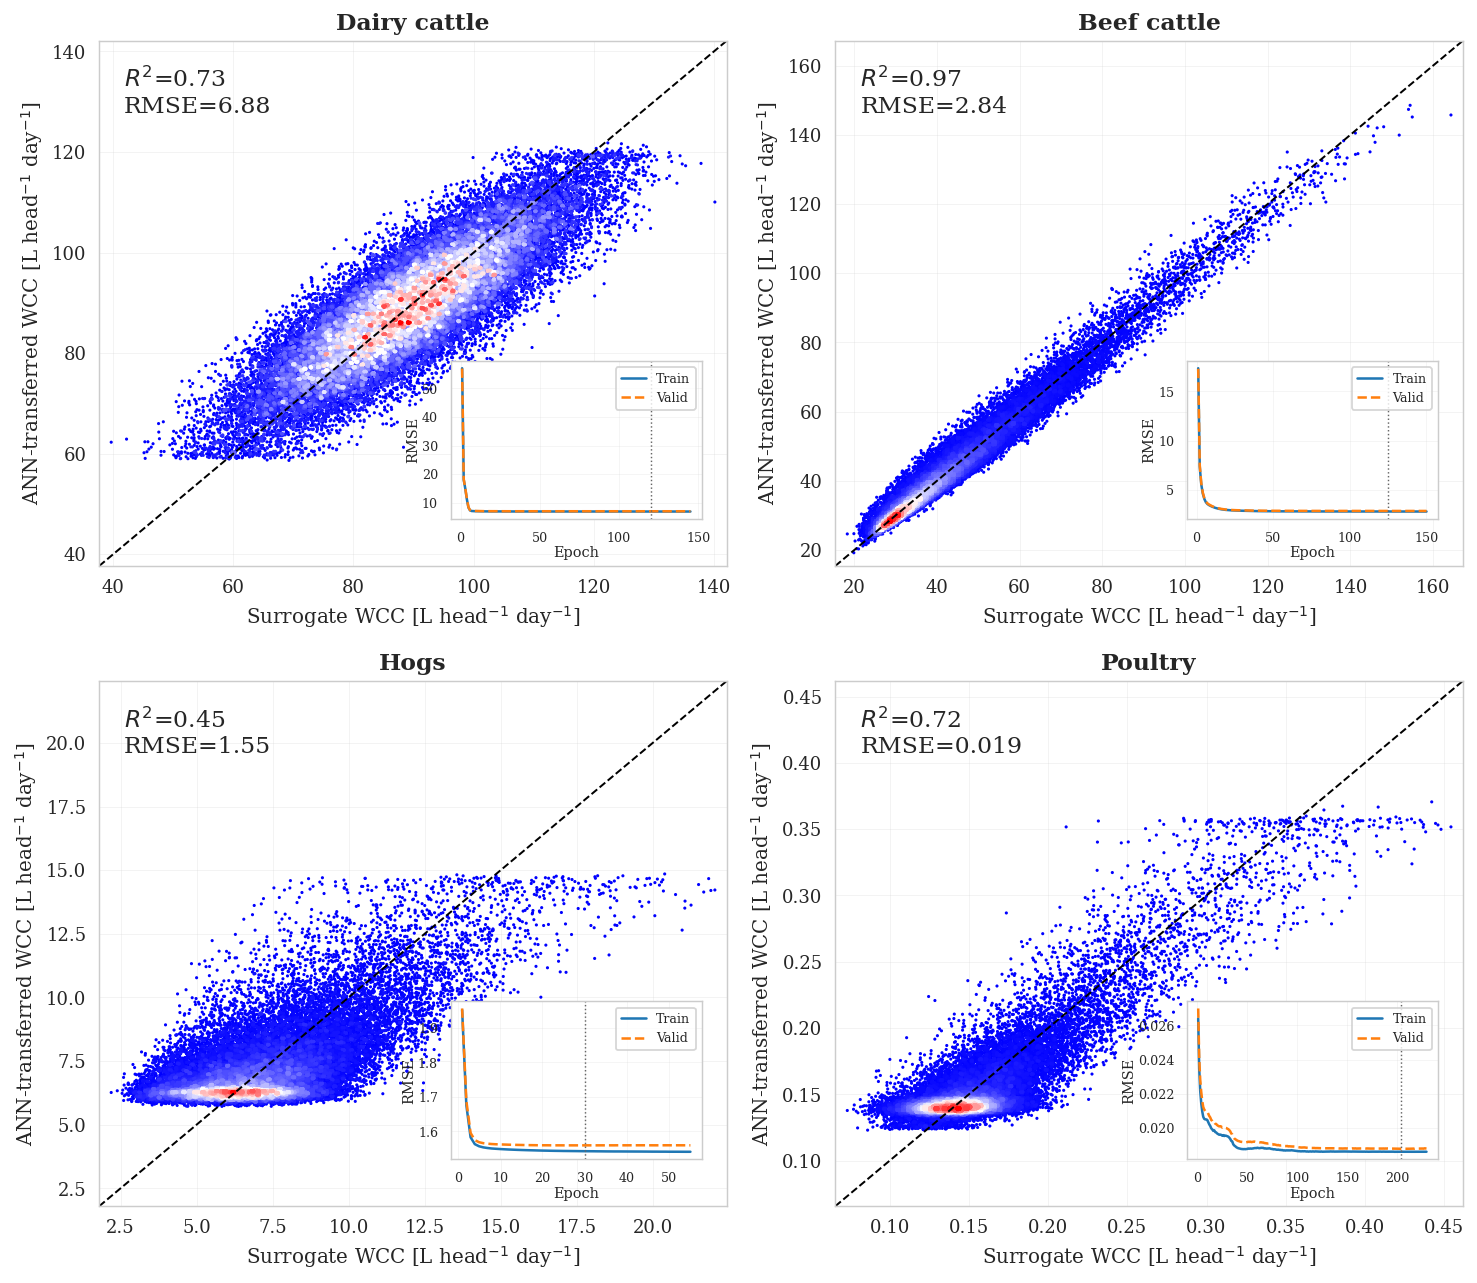

In [9]:
%run /scratch/hdagne1/LivestockWaterUse/figures/wcc_ANN_plot.py